# Problem

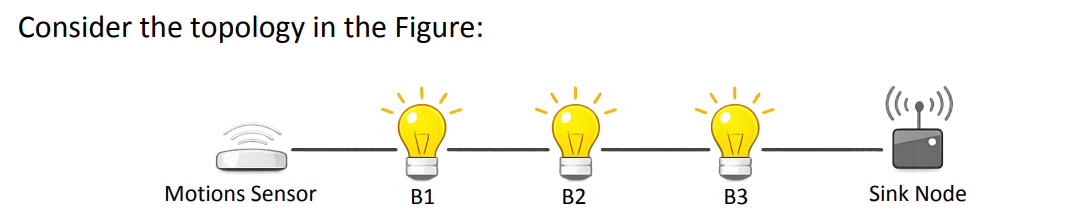

B1, B2, and B3 are Philips Hue White smart bulbs.

The presence sensor is an Aqara Motion Sensor P1.

The total distance between the presence sensor and the sink is: D = 40 m. Nodes are equally spaced.

Each transmission of a k = 2000 bit packet follows the energy model:

E_tx(k,d) = kE_c + kεd²
E_rx(k) = kE_c

where:

E_c = 300 nJ/bit
ε = 1 nJ/bit/m²

Assume ideal communication (no retransmissions, no idle energy).

# Question 1

Compute the total communication energy consumed by the network for one message in
the case of:
-  direct transmission
-  multi-hop transmission

In [10]:
E_c = 300 #nJ/bit
ε = 1 #nJ/bit/m²
D = 40 #m
k = 2000 #bit

## Calculating direct communication

The total energy consumption is calculated by summing the energy required to power the motion sensor ($k \cdot E_c$), the energy consumed during transmission from the sensor to the sink ($k \cdot \varepsilon \cdot D^2$), and finally the energy consumed by the sink ($k \cdot E_c$). This can be expressed as the following formula:$$E_{total} = (k \cdot E_c) + (k \cdot \varepsilon \cdot D^2) + (k \cdot E_c)$$

In [18]:
E_sensor_transmitting = k*E_c + k*ε*D*D
E_sink_receiving = k*E_c
E_direct = E_sensor_transmitting + E_sink_receiving #nJ
print("The energy consumed by the motion sensor to transmit directly to the sink is " + str(E_sensor_transmitting) + " nJ")
print("The energy consumed by transmitting directly is " + str(E_direct) + " nJ")

The energy consumed by the motion sensor to transmit directly to the sink is 3800000 nJ
The energy consumed by transmitting directly is 4400000 nJ


## Calculating hop by hop communication

In the hop-by-hop communication model with 4 nodes, the total energy consumption is calculated by summing the energy dissipated at each of the four hops. For each hop, we account for the energy required to power the transmitter ($k \cdot E_c$), the energy consumed by the radio amplifier to transmit over a quarter of the total distance ($k \cdot \varepsilon \cdot (D/4)^2$), and the energy consumed by the receiving node ($k \cdot E_c$).This can be expressed as the following formula:$$E_{HbyH} = 4 \times \left[ (k \cdot E_c) + \left(k \cdot \varepsilon \cdot \left(\frac{D}{4}\right)^2\right) + (k \cdot E_c) \right]$$

In [19]:
E_transmit_hopping = k*E_c+ k*ε*(D/4)*(D/4)
E_receiving_hopping = k*E_c
E_HbyH = (E_transmit_hopping + E_receiving_hopping)* 4 #nJ
print("The energy consumed by the motion sensor to transmit to the nearest bulb is " + str(E_transmit_hopping)+ " nJ")
print("The energy consumed by transmitting hop by hop is " + str(E_HbyH)+ " nJ")

The energy consumed by the motion sensor to transmit to the nearest bulb is 800000.0 nJ
The energy consumed by transmitting hop by hop is 5600000.0 nJ


# Question 2


## Which strategy would you choose for long-term operation?

We have selected the hop by hop strategy. The multi-hop approach drastically reduces the workload on the system's most energy-constrained component, which is the motion sensor.

## Which performance metric are you optimizing when choosing the strategy for long-term operation?

By shifting the energy burden from the battery-powered Aqara P1 sensor to the light bulbs, we are optimizing for the  System Lifetime. Basically we are ensuring that the sytem remains functional for the maximum possible duration before requiring physical maintenance or battery replacement.

## Provide a brief justification. Your explanation must clearly link the selected strategy to the chosen performance metric and be logically consistent with your numerical results.

The energy bottleneck of our circuit is the Aqara Motion Sensor since it relies on two CR2450 batteries. To maximize its lifetime and minimize interventions we minimize the energy consumption per transmission.
In the first scenario (the direct transmission) the sensor would consume 3.8 mJ (E_sensor_transmitting) per message, while in the second one (the hop by hop transmission) it consumes 0.8 mJ by only transmitting to the nearest bulb.
Even though the total network energy is higher in the multi-hop scenario (5.6 mJ vs 4.4 mJ), the extra energy is dissipated by the Philips Hue bulbs. These are connected directly to the building power's grid and are rated for a lifetime of 25 000 hours which means they can handle the additional transmission and reception costs without any risk to the system's overall operational longevity.